# 02 — Cohort & Retention Analysis

**Project:** Cohort & Retention Analysis  
**Business question:** *Which customers stopped buying, when did they leave, and why?*

This notebook turns the cleaned transaction table into a **cohort retention matrix**.

## What we're building

1. **Cohort month** = the month of each customer's *first* purchase.
2. **Cohort index** = number of months between an order and the customer's cohort month (0 = first month, 1 = next month, ...).
3. **Counts matrix**: rows = cohort month, cols = cohort index, values = # of unique customers from that cohort active in that month.
4. **Retention matrix**: each row of the counts matrix divided by its column-0 value, expressed as a percentage.
5. **Heatmap** of the retention triangle.
6. **CSV exports** for Tableau (wide + long format).

**Input:** `data/clean/online_retail_clean.parquet`  
**Outputs:** `data/clean/cohort_counts.csv`, `cohort_retention.csv`, `cohort_retention_long.csv`, `reports/cohort_retention_heatmap.png`

## 0. Imports & paths

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="white")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN_DIR    = PROJECT_ROOT / "data" / "clean"
REPORTS_DIR  = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(CLEAN_DIR / "online_retail_clean.parquet")
print("Loaded:", df.shape, "|", df["InvoiceDate"].min(), "→", df["InvoiceDate"].max())
df.head()

Loaded: (805549, 9) | 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


## 1. Assign each customer a cohort

We bucket every order into the **month it happened** (`InvoiceMonth`), then look up each customer's **earliest** `InvoiceMonth` and call that their `CohortMonth`. We attach the cohort back onto every row.

We use `pd.Period('M')` rather than truncating to a date because subtracting two `Period`s gives a clean *integer* month offset, which is exactly what `CohortIndex` needs.

In [2]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")
df["CohortMonth"]  = df.groupby("CustomerID")["InvoiceMonth"].transform("min")

# Months between this order's month and the customer's first-purchase month.
# Subtracting two PeriodIndex objects returns offsets — .apply(attrgetter('n')) gives ints.
df["CohortIndex"] = (df["InvoiceMonth"] - df["CohortMonth"]).apply(lambda off: off.n).astype("int16")

df[["CustomerID", "InvoiceDate", "InvoiceMonth", "CohortMonth", "CohortIndex"]].head(10)

,CustomerID,InvoiceDate,InvoiceMonth,CohortMonth,CohortIndex
0,13085,2009-12-01 07:45:00,2009-12,2009-12,0
1,13085,2009-12-01 07:45:00,2009-12,2009-12,0
2,13085,2009-12-01 07:45:00,2009-12,2009-12,0
3,13085,2009-12-01 07:45:00,2009-12,2009-12,0
4,13085,2009-12-01 07:45:00,2009-12,2009-12,0
5,13085,2009-12-01 07:45:00,2009-12,2009-12,0
6,13085,2009-12-01 07:45:00,2009-12,2009-12,0
7,13085,2009-12-01 07:45:00,2009-12,2009-12,0
8,13085,2009-12-01 07:46:00,2009-12,2009-12,0
9,13085,2009-12-01 07:46:00,2009-12,2009-12,0


**Quick sanity check** — every customer should have a `CohortIndex` of `0` in *exactly* the month equal to their `CohortMonth`.

In [3]:
bad = df[(df["CohortIndex"] == 0) & (df["InvoiceMonth"] != df["CohortMonth"])]
assert bad.empty, f"{len(bad)} rows have CohortIndex=0 but a different InvoiceMonth"
assert df["CohortIndex"].min() == 0, "CohortIndex should never be negative"
print("OK — CohortIndex aligns with CohortMonth on every row")
print("CohortIndex range:", df["CohortIndex"].min(), "→", df["CohortIndex"].max())

OK — CohortIndex aligns with CohortMonth on every row
CohortIndex range: 0 → 24


## 2. Build the counts matrix

For each (CohortMonth, CohortIndex) pair, count the **unique customers** who placed at least one order. `unstack` pivots `CohortIndex` into columns.

In [4]:
cohort_counts = (
    df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
      .nunique()
      .unstack(fill_value=0)
      .sort_index()
)

print("Matrix shape (cohorts × months-since-first-purchase):", cohort_counts.shape)
cohort_counts.head()

Matrix shape (cohorts × months-since-first-purchase): (25, 25)


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,955,337,319,406,363,343,360,327,321,346,403,473,359,270,233,289,251,289,270,248,244,301,291,389,188
2010-01,383,79,119,117,101,115,99,88,107,122,116,66,85,68,72,58,90,76,71,75,93,74,94,22,0
2010-02,374,89,84,109,92,75,72,107,95,103,43,47,57,65,46,75,60,61,54,86,86,61,22,0,0
2010-03,443,84,102,107,103,90,109,134,122,48,51,63,89,72,89,75,77,69,78,89,94,35,0,0,0
2010-04,294,57,57,48,54,66,81,77,31,32,22,41,41,46,46,46,41,44,53,66,17,0,0,0,0


## 3. Compute the retention matrix

Retention rate at month `N` for cohort `C` = `customers_active[C, N] / customers_active[C, 0]`.

Column 0 is always 100% (everyone bought in their own first month). Each subsequent column shows how much of the cohort is still active.

Because the dataset ends Dec 2011, **cells below the diagonal don't exist yet** — the December 2011 cohort has nothing past month 0. We leave those as `NaN` (rather than 0) so the heatmap shows a real triangle, not fake zeros.

In [5]:
cohort_sizes = cohort_counts.iloc[:, 0]
retention    = cohort_counts.divide(cohort_sizes, axis=0) * 100

# Mask cells that are structurally impossible (cohort_month + index > dataset_end)
max_month  = df["InvoiceMonth"].max()
for cohort in retention.index:
    months_possible = (max_month - cohort).n
    retention.loc[cohort, retention.columns > months_possible] = np.nan

retention.round(1).head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.3,33.4,42.5,38.0,35.9,37.7,34.2,33.6,36.2,42.2,49.5,37.6,28.3,24.4,30.3,26.3,30.3,28.3,26.0,25.5,31.5,30.5,40.7,19.7
2010-01,100.0,20.6,31.1,30.5,26.4,30.0,25.8,23.0,27.9,31.9,30.3,17.2,22.2,17.8,18.8,15.1,23.5,19.8,18.5,19.6,24.3,19.3,24.5,5.7,NaN
2010-02,100.0,23.8,22.5,29.1,24.6,20.1,19.3,28.6,25.4,27.5,11.5,12.6,15.2,17.4,12.3,20.1,16.0,16.3,14.4,23.0,23.0,16.3,5.9,NaN,NaN
2010-03,100.0,19.0,23.0,24.2,23.3,20.3,24.6,30.2,27.5,10.8,11.5,14.2,20.1,16.3,20.1,16.9,17.4,15.6,17.6,20.1,21.2,7.9,NaN,NaN,NaN
2010-04,100.0,19.4,19.4,16.3,18.4,22.4,27.6,26.2,10.5,10.9,7.5,13.9,13.9,15.6,15.6,15.6,13.9,15.0,18.0,22.4,5.8,NaN,NaN,NaN,NaN


## 4. Visualize the retention triangle

A heatmap where:
- **Rows** = cohort (sorted oldest at top)
- **Columns** = months since first purchase
- **Color** = retention %

The top-left is always 100. The further right you go, the more churn shows up. The bottom-right is empty because young cohorts haven't had time to age.

Saved heatmap → C:\Users\Pitu\Desktop\Claude\Cohort & Retention Analysis\reports\cohort_retention_heatmap.png


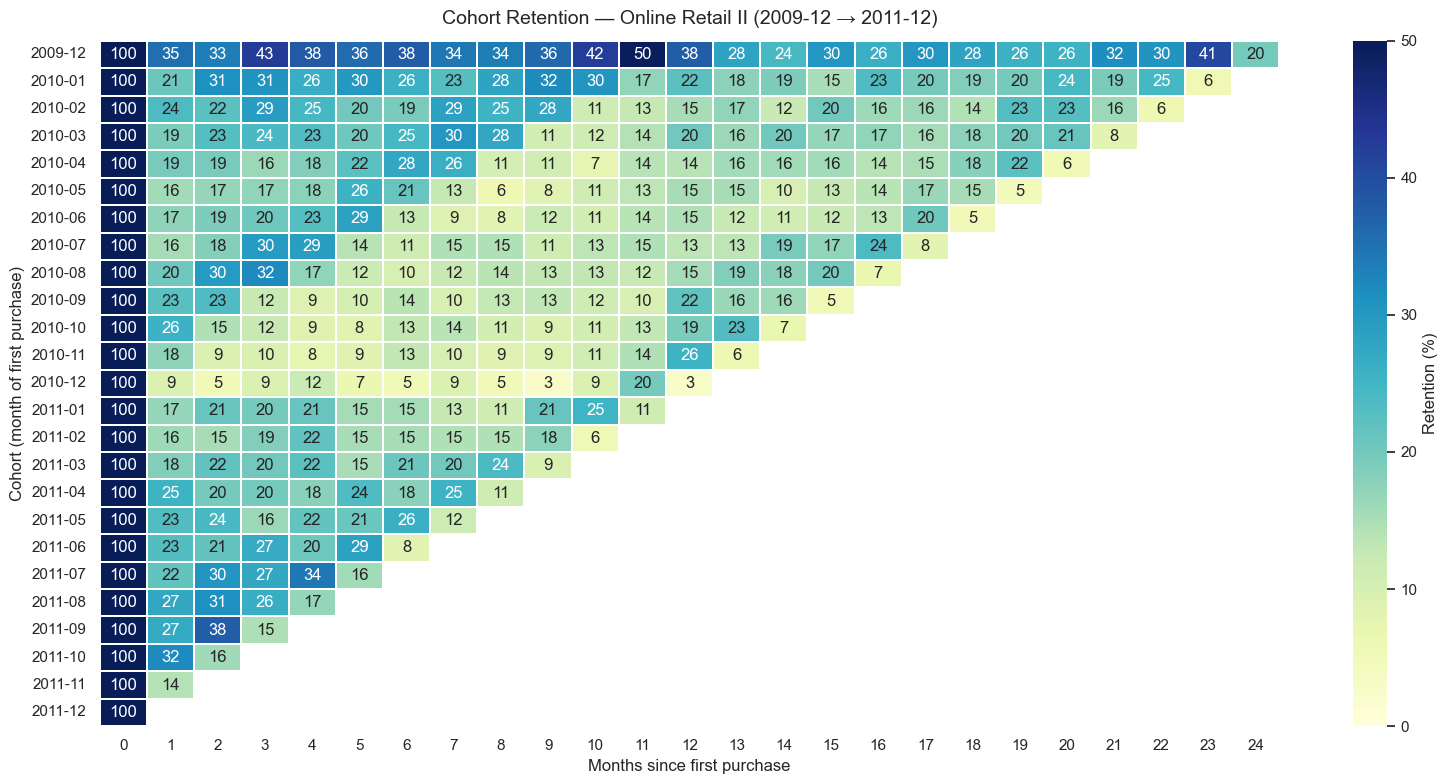

In [6]:
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    retention.astype(float),
    annot=True, fmt=".0f",
    cmap="YlGnBu",
    vmin=0, vmax=50,            # cap colour scale at 50% — anything above is bright
    cbar_kws={"label": "Retention (%)"},
    linewidths=0.3, linecolor="white",
    ax=ax,
)
ax.set_title("Cohort Retention — Online Retail II (2009-12 → 2011-12)", fontsize=14, pad=12)
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Cohort (month of first purchase)")
plt.tight_layout()

heatmap_path = REPORTS_DIR / "cohort_retention_heatmap.png"
fig.savefig(heatmap_path, dpi=150, bbox_inches="tight")
print("Saved heatmap →", heatmap_path)
plt.show()

## 5. Headline retention numbers

A few summary statistics worth quoting in the dashboard.

In [7]:
summary = pd.DataFrame({
    "avg retention %": retention.mean(axis=0).round(1),
    "cohorts contributing": retention.notna().sum(axis=0),
}).rename_axis("months since first purchase")

# Only show the headline indices (0, 1, 3, 6, 12) where they exist
headline_idx = [i for i in [0, 1, 3, 6, 12] if i in summary.index]
summary.loc[headline_idx]

,avg retention %,cohorts contributing
months since first purchase,,
0,100.0,25
1,21.2,24
3,21.6,22
6,17.8,19
12,18.2,13


In [8]:
print("Cohort sizes (customers in month 0):")
cohort_sizes.to_frame("new_customers")

Cohort sizes (customers in month 0):


,new_customers
CohortMonth,
2009-12,955
2010-01,383
2010-02,374
2010-03,443
2010-04,294
2010-05,254
2010-06,270
2010-07,186
2010-08,162


## 6. Export for Tableau

Three CSVs:

| File                                | Shape | Purpose                                            |
|-------------------------------------|-------|----------------------------------------------------|
| `cohort_counts.csv`                 | wide  | raw customer counts, useful for sanity-checks      |
| `cohort_retention.csv`              | wide  | retention %, easy to eyeball                       |
| `cohort_retention_long.csv`         | long  | tidy format for Tableau heatmaps (one row per cell) |

Tableau likes the long format — each row is one (cohort, month-index, retention%) tuple, with `CohortMonth` as a real date so Tableau can plot a time axis.

In [9]:
# Wide CSVs — convert PeriodIndex to a date for readability
counts_out = cohort_counts.copy()
counts_out.index = counts_out.index.to_timestamp()
counts_out.to_csv(CLEAN_DIR / "cohort_counts.csv")

retention_out = retention.round(2).copy()
retention_out.index = retention_out.index.to_timestamp()
retention_out.to_csv(CLEAN_DIR / "cohort_retention.csv")

# Long CSV — Tableau-friendly
long = (
    retention.round(2)
             .stack()
             .rename("RetentionPct")
             .reset_index()
)
long["CohortMonth"]  = long["CohortMonth"].dt.to_timestamp()
long["CohortSize"]   = long["CohortMonth"].map(
    {p.to_timestamp(): cohort_sizes.loc[p] for p in cohort_sizes.index}
)
long["ActiveCustomers"] = (long["RetentionPct"] / 100 * long["CohortSize"]).round().astype("Int64")
long = long[["CohortMonth", "CohortIndex", "CohortSize", "ActiveCustomers", "RetentionPct"]]
long.to_csv(CLEAN_DIR / "cohort_retention_long.csv", index=False)

print("Saved:")
for name in ["cohort_counts.csv", "cohort_retention.csv", "cohort_retention_long.csv"]:
    p = CLEAN_DIR / name
    print(f"  {p}  ({p.stat().st_size/1024:.1f} KB)")

long.head(10)

Saved:
  C:\Users\Pitu\Desktop\Claude\Cohort & Retention Analysis\data\clean\cohort_counts.csv  (2.0 KB)
  C:\Users\Pitu\Desktop\Claude\Cohort & Retention Analysis\data\clean\cohort_retention.csv  (2.5 KB)
  C:\Users\Pitu\Desktop\Claude\Cohort & Retention Analysis\data\clean\cohort_retention_long.csv  (14.8 KB)


,CohortMonth,CohortIndex,CohortSize,ActiveCustomers,RetentionPct
0,2009-12-01,0,955,955,100.00
1,2009-12-01,1,955,337,35.29
2,2009-12-01,2,955,319,33.40
3,2009-12-01,3,955,406,42.51
4,2009-12-01,4,955,363,38.01
5,2009-12-01,5,955,343,35.92
6,2009-12-01,6,955,360,37.70
7,2009-12-01,7,955,327,34.24
8,2009-12-01,8,955,321,33.61
9,2009-12-01,9,955,346,36.23


## Next: Phase 4 — Churn driver analysis (SQL)

We can now see *when* customers churn. The next notebook (`03_churn_drivers.ipynb`) and SQL scripts in `sql/` will dig into *why* — comparing returning vs lapsed customers across:

1. **Recency / frequency / monetary** — were they low-value to start with?
2. **Product mix** — did one-time buyers cluster around specific products/categories?
3. **Geography** — does churn vary by country?